# Gpd.ipynb

Will transform each pose into gpd, reduce pose vector dimensionality and pool them across frames to construct full frame vector


In [1]:
import numpy as np
from gpd_utils import*
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import defaultdict


#importing cleaned annotations
try:
    with open('cleanedAnnots.pkl', 'rb') as f:
        annots = pickle.load(f)
except:
    print("Error")

## Computing gpd frames

In [2]:
#computing gpd frames

for day in annots:
    for operation in annots[day]:
        for frame in annots[day][operation]:
            for pose in frame['poses']:
                pose['gpdRep'] = computeGpd(pose['keypoints'])



In [3]:
#checkign results and shape
exKp = annots['day1']['operation_1'][0]['poses'][0]['gpdRep']
print(exKp)
print(np.shape(exKp))

[-7.96225710e+01 -3.30422359e+02 -4.84866925e+02 -6.11674283e+01
 -2.82226002e+02 -3.93266147e+02  7.21112124e+01 -2.96444304e+02
 -2.84142760e+02 -2.23406525e+02 -3.08399793e+02 -2.05479802e+02
  1.32257609e+02 -7.79397364e+01 -1.63777397e+00 -1.32257609e+02
  7.79397364e+01  1.63777397e+00  1.96674013e+02 -1.93700907e+02
 -7.69349218e+01 -2.53728753e+02 -9.44892647e+01 -3.44574898e+01
  2.37054558e+02  2.35795098e+01 -6.60458271e+01 -2.77735777e+02
  1.14364473e+02  7.70428548e+01  2.42674156e+02  9.22470913e+01
 -1.02152358e+02 -3.15366448e+02  1.40538897e+02  8.29418261e+01
  1.05138878e+02  2.53905179e+02  3.14985688e+02  5.84936833e+02
  6.37351450e+02  5.11313091e+02  5.37443994e+02  6.33255746e+02
  7.43523214e+02  6.54977163e+02  7.74458816e+02  1.72838855e+02
  2.49540183e+02  4.82202142e+02  5.39186684e+02  4.17593517e+02
  4.48406734e+02  5.38076669e+02  6.52208872e+02  5.63291260e+02
  6.85653947e+02  3.06041709e+02  3.62175237e+02  5.13420430e+02
  2.62692187e+02  4.57493

In [4]:
#stacking all poses into matrix
gpdList = [] 

frameIds = []  #will be used later when averaging gpd vectors per frame

for day in annots:
    for operation in annots[day]:
        for frame in annots[day][operation]:
            for pose in frame['poses']:
                gpdList.append(pose['gpdRep'])
                frameIds.append((day, operation, frame['frameIdx']))


gpdMatrix = np.array(gpdList)

In [5]:
#checking shape, should be (1058,749)
np.shape(gpdMatrix)

(1058, 749)

## Reducing dimensionality


In [6]:
#features in gpd are of different scales: dist in mm, angles between 0 and pi thus we standardize the values
scaler = StandardScaler()
gpdMatrixScaled = scaler.fit_transform(gpdMatrix)

In [7]:
#fitting pca
pca = PCA()
pca.fit(gpdMatrixScaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


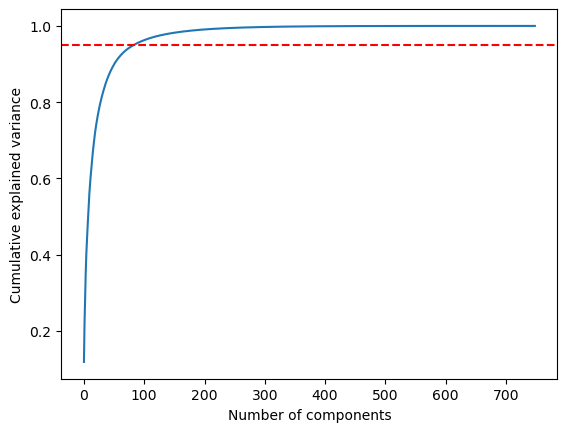

In [10]:
#plotting explained variance to find optimal number of components
cumVar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumVar)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()


As shown in the plot, explained variability rises rapidly until 50 components then flattens significantly and crosses the 95% threshold at 100 components. Thus given that diversity features and scene graphs features have less components. We'll fit pca with 50 components so that it doesnt dominate as much.

In [11]:
pca = PCA(n_components=50)
gpdReduced = pca.fit_transform(gpdMatrixScaled)

In [12]:
#Averaging gpd per frame
frameGpd = defaultdict(list)

#appending corresponding poses to frame
for i, frameId in enumerate(frameIds):
    frameGpd[frameId].append(gpdReduced[i])

#averaging per frame
frameGpdMean = {}
for frameId, vectors in frameGpd.items():
    frameGpdMean[frameId] = np.mean(vectors, axis=0)

In [13]:
#ensuring right number of frames (should be 626)
len(frameGpdMean)

626

In [14]:
#adding gpd frame mean to annotations
for frameId, vector in frameGpdMean.items():
    for frame in annots[frameId[0]][frameId[1]]:
        if frameId[2] == frame['frameIdx']:
            frame['meanGpd'] = vector
            break

In [15]:
#inspecting results
frame = annots['day1']['operation_1'][0]['meanGpd']
print(frame)


[-2.03604819  3.73531844 -5.61706225 10.84507064 -2.27416463  1.98146815
 -6.51115003  6.39261481 -1.66791456  2.20409966 -3.29853833  2.61399092
 -0.07261578  4.20513715 -2.11174064  1.92476003 -4.62633145  0.71075047
 -4.55930909 -4.07518399  6.13447405  1.59038266  0.38904992  0.83059951
  2.64690195 -0.71753511 -0.79012848  0.40934643  1.4188732   0.14733229
 -1.09987446  2.63133643  2.09781285 -0.14712467  1.80398085  0.49811042
  2.32070197 -5.68718897  4.35899591  0.21602699  1.20369212 -1.04941543
 -2.1692311   1.60748058 -1.88370103  0.6778027   3.09028142 -2.13164011
  1.22110882  2.70380443]


In [16]:
print(np.shape(frame))

(50,)


In [17]:
##exporting annotations with added gpd
import pickle 

with open('gpdAnnots.pkl', 'wb') as f:
    pickle.dump(annots, f)
    